### Very Large Gaps Imputation (Months to Years) (over 30 days) (>720 hours)

In [1]:
from pathlib import Path
from datetime import timedelta

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
def load_cleaned_data(station_id, directory = "./output"):
    filename = Path(directory) / f"Station{station_id}_filled_mediumgaps.csv"
    df = pd.read_csv(filename, parse_dates=[0], index_col=0)
    df.index = pd.DatetimeIndex(df.index, freq="H")
    return df

def load_missing_data(station_id, directory="../EDA_2025/missing_data"):
    filename = f"{directory}/Station{station_id}_missing_data.csv"
    df = pd.read_csv(filename, parse_dates=["Start Timestamp", "End Timestamp"])
    return df

In [3]:
load_cleaned_data(1).head()

,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Flag,Tair,RH,Wind speed,Wind direction,Srad,Ppt
2015-01-01 00:00:00,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,3,-1.090,81.5,1.052,52.27,0.63,0.0
2015-01-01 01:00:00,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,3,-1.038,81.7,0.959,46.71,0.62,0.0
2015-01-01 02:00:00,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,3,-0.981,82.0,1.062,52.04,0.60,0.0
2015-01-01 03:00:00,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,3,-0.814,81.9,0.887,58.91,0.64,0.0
2015-01-01 04:00:00,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,3,-0.805,90.0,0.828,16.55,0.20,0.0


In [4]:
def filter_very_long_gaps(df_missing, parameter, min_gap=720):
    df_missing["Number Missing"] = pd.to_numeric(
        df_missing["Number Missing"], errors="coerce"
    )
    mask = (df_missing["Parameter"] == parameter) & (
        df_missing["Number Missing"] >= min_gap
    )
    return df_missing.loc[mask].sort_values("Start Timestamp")

In [5]:
def choose_best_donor(target_series, donors):
    best_sid, best_r = None, -np.inf
    for sid, donor_series in donors.items():
        overlap = target_series.notna() & donor_series.notna()
        if overlap.sum() < 1000:  # At least 6 weeks here
            continue
        r = target_series[overlap].corr(donor_series[overlap])
        if abs(r) > best_r:
            best_sid, best_r = sid, abs(r)
    return best_sid, best_r

In [6]:
def fit_linear_map(target_series, donor_series):
    mask = target_series.notna() & donor_series.notna()
    X = donor_series[mask].values.reshape(-1, 1)
    y = target_series[mask].values
    model = LinearRegression().fit(X, y)
    return model

In [7]:
def apply_fill(target_df, donor_df, gaps, param, model):
    for _, row in gaps.iterrows():
        start, end = row["Start Timestamp"], row["End Timestamp"]
        rng = pd.date_range(start=start, end=end, freq="H")
        donor_slice = donor_df.loc[rng, param]

        avail = donor_slice.notna()
        if avail.sum() == 0:
            continue

        preds = model.predict(donor_slice[avail].values.reshape(-1, 1))
        target_df.loc[donor_slice.index[avail], param] = preds
    return target_df

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates
from datetime import timedelta
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

def main(target_station=1, donor_candidates=(2, 3, 4, 5, 6), params=("SWC_5", "SWC_10", "SWC_20", "SWC_50"),out_dir="./output", win_days=14
):
    print(f"\n=== Filling VERY-LONG gaps for Station{target_station} ===")

    # Load the data
    df_before = load_cleaned_data(target_station)
    df_tgt    = df_before.copy() 
    donors = {sid: load_cleaned_data(sid) for sid in donor_candidates if sid != target_station}
    missing_df = load_missing_data(target_station)

    # Process each SWC parameter separately
    for p in params:
        print(f"\n[Parameter] {p}")

        long_gaps = filter_very_long_gaps(missing_df, p)
        if long_gaps.empty:
            print("  • No very-long gaps detected, skip.")
            continue

        # Choose donor
        donor_sid, r_abs = choose_best_donor(
            df_tgt[p], {sid: donors[sid][p] for sid in donors}
        )
        if donor_sid is None:
            print("  • No donor with sufficient overlap, skip.")
            continue
        print(f"  • Best donor → Station{donor_sid}  |r| = {r_abs:.3f}")

        # Fit linear mapping y = a·x + b on overlapping hours
        model = fit_linear_map(df_tgt[p], donors[donor_sid][p])
        a = model.coef_[0]
        b = model.intercept_
        print(f"    Mapping  y ≈ {a:.3f}·x + {b:.3f}")

        # Apply mapping to fill each very-long gap
        before = df_tgt[p].isna().sum()
        df_tgt = apply_fill(df_tgt, donors[donor_sid], long_gaps, p, model)
        after = df_tgt[p].isna().sum()
        print(f"    Filled {before - after} points   (remaining NaN: {after})")

        # cross-validation with drop-out 10 % of joint-non-NaN
        joint_ok = df_tgt[p].notna() & donors[donor_sid][p].notna()
        if joint_ok.sum() < 100:             # too few points → skip CV
            print("    CV-like check skipped (insufficient overlap).")
            continue
            
        mask_idx = joint_ok[joint_ok].sample(frac=0.1, random_state=0).index
        y_true   = df_tgt.loc[mask_idx, p].values
        X_donor  = donors[donor_sid].loc[mask_idx, p].values.reshape(-1, 1)
        y_pred   = model.predict(X_donor)

        mae  = mean_absolute_error(y_true, y_pred)
        mse  = mean_squared_error(y_true, y_pred)
        rmse = mse ** 0.5
        print(f"    CV-like check  MAE={mae:.4f}  MSE={mse:.4f}  RMSE={rmse:.4f}")

        if True:
            for _, row in long_gaps.iterrows():
                start, end = row["Start Timestamp"], row["End Timestamp"]
                win = slice(start - timedelta(days=win_days),
                            end   + timedelta(days=win_days))

                fig, ax = plt.subplots(figsize=(11, 3))
                ax.plot(df_tgt.loc[win, p],      label="Filled"  , lw=1.3)
                ax.plot(donors[donor_sid].loc[win, p],
                        label=f"Donor S{donor_sid}", ls="--", alpha=.6)

                ax.axvspan(start, end, color="orange", alpha=.12)
                ax.set_title(f"Station{target_station}  {p}  "
                             f"gap {start:%Y-%m-%d} — {end:%Y-%m-%d}")
                ax.set_ylabel("Volumetric SWC")
                ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
                ax.legend(frameon=False)
                plt.tight_layout()

                plt.show()     

In [9]:
main(
    target_station = 1,
    donor_candidates = (2, 3, 4, 5, 6)
)


=== Filling VERY-LONG gaps for Station1 ===

[Parameter] SWC_5
  • No very-long gaps detected, skip.

[Parameter] SWC_10
  • No very-long gaps detected, skip.

[Parameter] SWC_20
  • No very-long gaps detected, skip.

[Parameter] SWC_50
  • No very-long gaps detected, skip.



=== Filling VERY-LONG gaps for Station2 ===

[Parameter] SWC_5
  • Best donor → Station3  |r| = 0.906
    Mapping  y ≈ 1.185·x + -0.015
    Filled 2075 points   (remaining NaN: 0)
    CV-like check  MAE=0.0181  MSE=0.0007  RMSE=0.0265


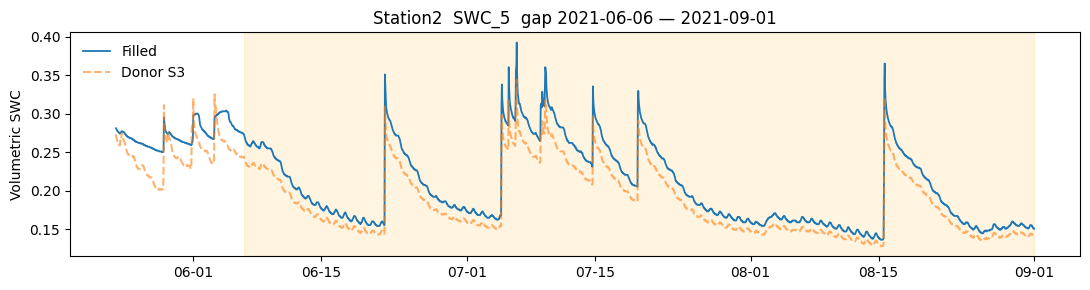


[Parameter] SWC_10
  • Best donor → Station3  |r| = 0.899
    Mapping  y ≈ 0.913·x + -0.028
    Filled 2075 points   (remaining NaN: 0)
    CV-like check  MAE=0.0175  MSE=0.0006  RMSE=0.0245


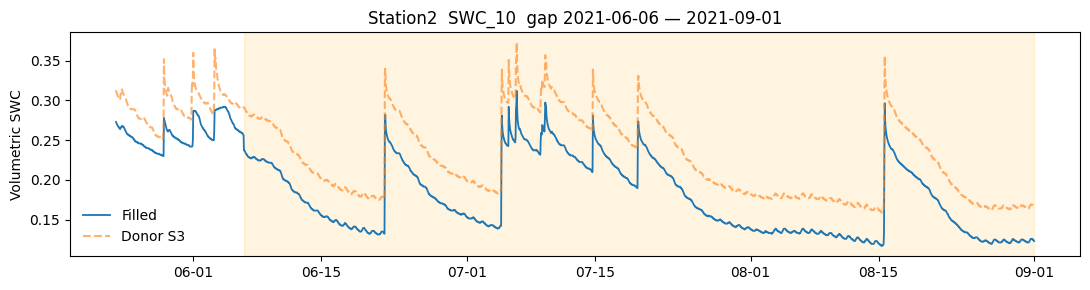


[Parameter] SWC_20
  • Best donor → Station3  |r| = 0.907
    Mapping  y ≈ 0.830·x + 0.006
    Filled 2075 points   (remaining NaN: 0)
    CV-like check  MAE=0.0168  MSE=0.0006  RMSE=0.0247


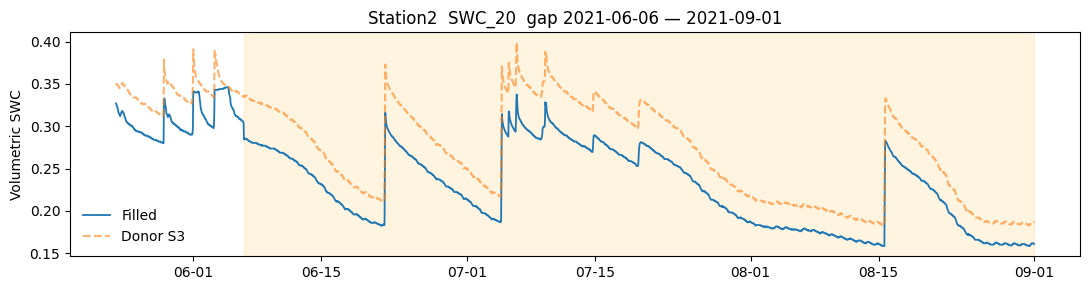


[Parameter] SWC_50
  • Best donor → Station3  |r| = 0.932
    Mapping  y ≈ 1.230·x + 0.018
    Filled 2075 points   (remaining NaN: 0)
    CV-like check  MAE=0.0239  MSE=0.0010  RMSE=0.0315


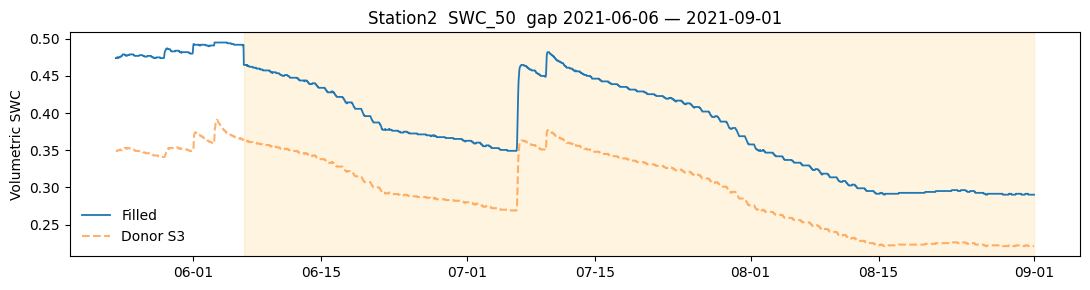

In [10]:
main(
    target_station = 2,
    donor_candidates = (1, 3, 4, 5, 6)
)

In [11]:
main(
    target_station = 3,
    donor_candidates = (1, 2, 4, 5, 6)
)


=== Filling VERY-LONG gaps for Station3 ===

[Parameter] SWC_5
  • No very-long gaps detected, skip.

[Parameter] SWC_10
  • No very-long gaps detected, skip.

[Parameter] SWC_20
  • No very-long gaps detected, skip.

[Parameter] SWC_50
  • No very-long gaps detected, skip.


In [12]:
main(
    target_station = 4,
    donor_candidates = (1, 2, 3, 5, 6)
)


=== Filling VERY-LONG gaps for Station4 ===

[Parameter] SWC_5
  • No very-long gaps detected, skip.

[Parameter] SWC_10
  • No very-long gaps detected, skip.

[Parameter] SWC_20
  • No very-long gaps detected, skip.

[Parameter] SWC_50
  • No donor with sufficient overlap, skip.



=== Filling VERY-LONG gaps for Station5 ===

[Parameter] SWC_5
  • No very-long gaps detected, skip.

[Parameter] SWC_10
  • No very-long gaps detected, skip.

[Parameter] SWC_20
  • Best donor → Station2  |r| = 0.891
    Mapping  y ≈ 0.861·x + 0.065
    Filled 9973 points   (remaining NaN: 0)
    CV-like check  MAE=0.0140  MSE=0.0005  RMSE=0.0227


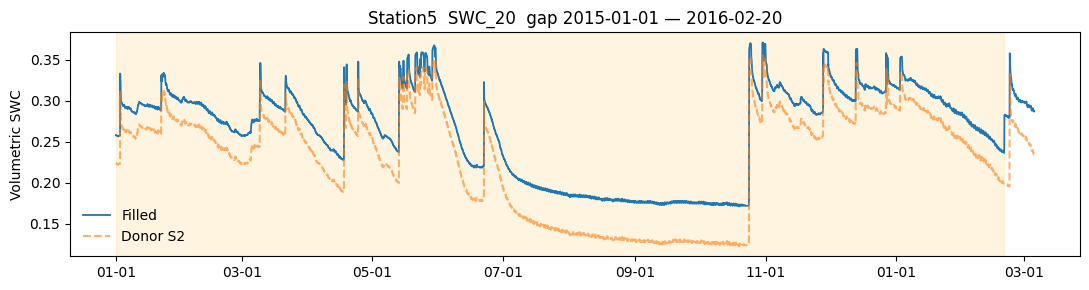


[Parameter] SWC_50
  • No very-long gaps detected, skip.


In [13]:
main(
    target_station = 5,
    donor_candidates = (1, 2, 3, 4, 6)
)

In [14]:
main(
    target_station = 6,
    donor_candidates = (1, 2, 3, 4, 5)
)


=== Filling VERY-LONG gaps for Station6 ===

[Parameter] SWC_5
  • No very-long gaps detected, skip.

[Parameter] SWC_10
  • No very-long gaps detected, skip.

[Parameter] SWC_20
  • No very-long gaps detected, skip.

[Parameter] SWC_50
  • No very-long gaps detected, skip.


## GPS Locations
1- Latitude 30.3989 Longitude -98.6105 Logger ID CR1000-5

2- Latitude 30.4193 Longitude -98.8046 Logger ID CR200-26 (CR1000-1)

3- Latitude 30.4421 Longitude -98.8427 Logger ID CR1000-6

4- Latitude 30.4600 Longitude -98.9407 Logger ID CR1000-4

5- Latitude 30.2454 Longitude -98.7059 Logger ID CR1000-2

6- Latitude 30.2758 Longitude -98.7242 Logger ID CR1000-3

By calculation, 

In [15]:
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2


coords = {
    1: (30.3989, -98.6105),
    2: (30.4193, -98.8046),
    3: (30.4421, -98.8427),
    4: (30.4600, -98.9407),
    5: (30.2454, -98.7059),
    6: (30.2758, -98.7242),
}

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0  # r km
    φ1, φ2 = map(radians, (lat1, lat2))
    Δφ     = radians(lat2-lat1)
    Δλ     = radians(lon2-lon1)
    a = sin(Δφ/2)**2 + cos(φ1)*cos(φ2)*sin(Δλ/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1-a))


PARAMS   = ["SWC_5", "SWC_10", "SWC_20", "SWC_50"]
STATIONS = [1, 2, 3, 4, 5, 6]        

rows = []
for i in STATIONS:
    df_i = load_cleaned_data(i)
    for j in STATIONS:
        if i == j:
            continue
        df_j = load_cleaned_data(j)

        r_vals = {}
        for p in PARAMS:
            mask = df_i[p].notna() & df_j[p].notna()
            r_vals[p] = df_i.loc[mask, p].corr(df_j.loc[mask, p]) if mask.any() else np.nan

        dist = haversine_km(*coords[i], *coords[j])

        rows.append({
            "Target": i,
            "Donor" : j,
            "Distance_km": round(dist, 2),
            **{f"r_{p}": round(r_vals[p], 3) for p in PARAMS}
        })

corr_df = pd.DataFrame(rows).sort_values(["Target", "Distance_km"])
corr_df

,Target,Donor,Distance_km,r_SWC_5,r_SWC_10,r_SWC_20,r_SWC_50
4,1,6,17.51,0.898,0.764,0.886,0.689
0,1,2,18.75,0.812,0.871,0.884,0.827
3,1,5,19.37,0.780,0.828,0.844,0.767
1,1,3,22.78,0.837,0.875,0.837,0.804
2,1,4,32.38,0.788,0.822,0.817,NaN
6,2,3,4.45,0.906,0.899,0.907,0.932
7,2,4,13.81,0.872,0.860,0.864,NaN
9,2,6,17.72,0.778,0.799,0.811,0.527
5,2,1,18.75,0.812,0.871,0.884,0.827
8,2,5,21.53,0.879,0.876,0.891,0.799
